# Healthcare Analytics

## Project Overview

This project analyzes a synthetic healthcare dataset to explore patient demographics, medical conditions, hospital admissions, billing, insurance providers, medications, test results, and admission trends.

Python is used for data cleaning, feature engineering, exploratory data analysis, and visualization. SQL will be used to answer selected business questions, while Power BI will be used to develop an interactive healthcare analytics dashboard.

The objective is to identify patterns and relationships within the dataset and demonstrate an end-to-end data analytics workflow.

## 1. Import Library

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [60]:
df = pd.read_csv("healthcare_dataset.csv")

## 3. Initial Data Inspection

In [61]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [62]:
df.shape

(55500, 15)

In [63]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [65]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [66]:
df.duplicated().sum()

np.int64(534)

## 4. Duplicate Record Analysis

In [67]:
df[df.duplicated(keep=False)].head(20)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,08-05-2020,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168890,378,Emergency,01-06-2020,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,05-03-2021,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477820,361,Emergency,20-03-2021,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,06-05-2021,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782090,451,Elective,29-05-2021,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,23-06-2021,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,09-07-2021,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,27-02-2020,Erica Mccormick,Donaldson-Frey,Medicare,41939.119940,453,Elective,26-03-2020,Ibuprofen,Normal
246,wiLlIAm mcCOY,80,Male,A-,Asthma,20-02-2023,Whitney Vaughan,"and Walker Glenn, Long",Cigna,3845.397496,158,Emergency,10-03-2023,Penicillin,Normal
360,tHOMas DENnIs,40,Male,A+,Asthma,28-01-2024,Leonard Chen,Mckinney-Edwards,Medicare,42959.299810,410,Elective,21-02-2024,Paracetamol,Abnormal
408,MelIssA hOFfMAN,36,Male,B+,Cancer,27-07-2022,April Cummings,Cooley-Reid,Cigna,41311.293900,434,Emergency,19-08-2022,Lipitor,Inconclusive
454,jOrdan LEON,51,Female,O+,Arthritis,11-08-2023,Christina Lopez,Dennis-Roth,Cigna,21534.715570,198,Emergency,20-08-2023,Penicillin,Normal
621,JesSIcA caRtER,51,Female,A-,Obesity,08-12-2019,Sarah Ibarra,Anderson Group,Cigna,32006.031570,200,Urgent,05-01-2020,Penicillin,Normal


In [68]:
df[df.duplicated(keep=False)].shape

(1068, 15)

In [69]:
df[df.duplicated(keep=False)].sort_values("Name").head(20)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
54285,ABIgaIL YOung,41,Female,O+,Hypertension,15-12-2022,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,13-01-2023,Ibuprofen,Normal
42407,ABIgaIL YOung,41,Female,O+,Hypertension,15-12-2022,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,13-01-2023,Ibuprofen,Normal
26025,ALIcia taYLoR,78,Male,O+,Asthma,18-09-2022,Dawn Burton,Wright LLC,Aetna,31465.274980,149,Elective,15-10-2022,Aspirin,Inconclusive
53104,ALIcia taYLoR,78,Male,O+,Asthma,18-09-2022,Dawn Burton,Wright LLC,Aetna,31465.274980,149,Elective,15-10-2022,Aspirin,Inconclusive
50151,AMy GREEN,79,Female,B+,Obesity,30-03-2021,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358490,249,Elective,27-04-2021,Penicillin,Abnormal
42323,AMy GREEN,79,Female,B+,Obesity,30-03-2021,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358490,249,Elective,27-04-2021,Penicillin,Abnormal
51695,ANDREA HansEN,61,Male,O+,Cancer,02-07-2021,Alisha Flores,LLC Clark,Cigna,40026.763950,254,Elective,22-07-2021,Paracetamol,Normal
21675,ANDREA HansEN,61,Male,O+,Cancer,02-07-2021,Alisha Flores,LLC Clark,Cigna,40026.763950,254,Elective,22-07-2021,Paracetamol,Normal
51916,ANDrEA fREnCH,73,Male,A-,Arthritis,08-02-2021,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,24-02-2021,Ibuprofen,Inconclusive
36207,ANDrEA fREnCH,73,Male,A-,Arthritis,08-02-2021,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,24-02-2021,Ibuprofen,Inconclusive


## 5. Numerical Data Overview

In [70]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224655,202.000000
50%,52.000000,25538.069380,302.000000
75%,68.000000,37820.508432,401.000000
max,89.000000,52764.276740,500.000000


## 6. Categorical Data Overview

In [71]:
df["Gender"].value_counts()

,count
Gender,
Male,27774
Female,27726


In [72]:
df["Medical Condition"].value_counts()

,count
Medical Condition,
Arthritis,9308
Diabetes,9304
Hypertension,9245
Obesity,9231
Cancer,9227
Asthma,9185


In [73]:
df["Admission Type"].value_counts()

,count
Admission Type,
Elective,18655
Urgent,18576
Emergency,18269


In [74]:
df["Test Results"].value_counts()

,count
Test Results,
Abnormal,18627
Normal,18517
Inconclusive,18356


In [75]:
df["Insurance Provider"].value_counts()

,count
Insurance Provider,
Cigna,11249
Medicare,11154
UnitedHealthcare,11125
Blue Cross,11059
Aetna,10913


## 7. Data Quality Investigation

In [76]:
##Negative billing

df[df["Billing Amount"] < 0]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,05-11-2019,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,23-11-2019,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,16-02-2023,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,09-03-2023,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,21-12-2021,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,11-01-2022,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,20-01-2021,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,09-02-2021,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,21-03-2021,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,17-04-2021,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52894,JosEPh cOx,23,Male,AB-,Diabetes,13-10-2019,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,25-10-2019,Lipitor,Inconclusive
53204,AsHley WaRnER,55,Male,A+,Hypertension,21-12-2021,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,11-01-2022,Ibuprofen,Normal
53232,dAnIel dRaKe,68,Female,B+,Hypertension,24-04-2020,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,26-04-2020,Lipitor,Abnormal
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,31-05-2019,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663794,122,Urgent,12-06-2019,Ibuprofen,Abnormal


In [77]:
df[df["Billing Amount"] < 0].shape

(108, 15)

In [78]:
##Dates

df["Date of Admission"].head(10)

,Date of Admission
0,31-01-2024
1,20-08-2019
2,22-09-2022
3,18-11-2020
4,19-09-2022
5,20-12-2023
6,03-11-2020
7,28-12-2021
8,01-07-2020
9,23-05-2021


In [79]:
df["Discharge Date"].head(10)

,Discharge Date
0,02-02-2024
1,26-08-2019
2,07-10-2022
3,18-12-2020
4,09-10-2022
5,24-12-2023
6,15-11-2020
7,07-01-2022
8,14-07-2020
9,22-06-2021


In [80]:
df["Date of Admission"].nunique()

1827

In [81]:
df["Discharge Date"].nunique()

1856

In [82]:
##age

df["Age"].value_counts().sort_index().head(10)

,count
Age,
13,14
14,18
15,28
16,24
17,32
18,772
19,805
20,750
21,822


In [83]:
df["Age"].value_counts().sort_index().tail(10)

,count
Age,
80,864
81,818
82,797
83,792
84,780
85,743
86,41
87,31
88,25


##8. Date Validation

In [84]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    format="%d-%m-%Y")

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    format="%d-%m-%Y")

In [85]:
df[["Date of Admission", "Discharge Date"]].head()

,Date of Admission,Discharge Date
0,2024-01-31,2024-02-02
1,2019-08-20,2019-08-26
2,2022-09-22,2022-10-07
3,2020-11-18,2020-12-18
4,2022-09-19,2022-10-09


In [86]:
df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]).dt.days

In [87]:
df["Length of Stay"].describe()

,Length of Stay
count,55500.000000
mean,15.509009
std,8.659600
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000


In [88]:
df[df["Length of Stay"] < 0]


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


In [89]:
df[df["Length of Stay"] == 0].shape

(0, 16)

In [90]:
df[df["Billing Amount"] < 0][
    ["Name", "Age", "Billing Amount", "Date of Admission", "Discharge Date"]].head(20)

,Name,Age,Billing Amount,Date of Admission,Discharge Date
132,ashLEy ERIcKSoN,32,-502.507813,2019-11-05,2019-11-23
799,CHRisTOPHer wEiss,49,-1018.245371,2023-02-16,2023-03-09
1018,AsHley WaRnER,60,-306.364925,2021-12-21,2022-01-11
1421,JAY galloWaY,74,-109.097122,2021-01-20,2021-02-09
2103,josHUa wilLIamSon,72,-576.727907,2021-03-21,2021-04-17
2696,Scott VaZqUEz,74,-135.986000,2023-04-12,2023-05-03
2855,CaROl aNDErSoN,39,-370.983674,2020-04-03,2020-04-10
3772,mr. ChRIStOPhER aLvARaDO,77,-1310.272895,2022-06-03,2022-06-13
5445,ALExAndrA KHaN,32,-692.408820,2022-07-14,2022-07-19
5708,JosEPh cOx,23,-353.865186,2019-10-13,2019-10-25


##9. Data Cleaning

In [91]:
df.shape

(55500, 16)

In [92]:
df.duplicated().sum()

np.int64(534)

In [93]:
df = df.drop_duplicates()

In [94]:
df.shape

(54966, 16)

In [95]:
##Verify
df.duplicated().sum()

np.int64(0)

In [96]:
df[df["Billing Amount"] < 0].shape

(106, 16)

In [97]:
df["Billing Amount"].min()

-2008.49214

In [98]:
df[df["Billing Amount"] < 0][
    ["Name", "Age", "Medical Condition", "Billing Amount"]].head(20)

,Name,Age,Medical Condition,Billing Amount
132,ashLEy ERIcKSoN,32,Cancer,-502.507813
799,CHRisTOPHer wEiss,49,Asthma,-1018.245371
1018,AsHley WaRnER,60,Hypertension,-306.364925
1421,JAY galloWaY,74,Asthma,-109.097122
2103,josHUa wilLIamSon,72,Diabetes,-576.727907
2696,Scott VaZqUEz,74,Diabetes,-135.986000
2855,CaROl aNDErSoN,39,Hypertension,-370.983674
3772,mr. ChRIStOPhER aLvARaDO,77,Obesity,-1310.272895
5445,ALExAndrA KHaN,32,Arthritis,-692.408820
5708,JosEPh cOx,23,Diabetes,-353.865186


##10. Handling invalid billing amounts

In [99]:
df["Billing Valid"] = df["Billing Amount"] >= 0

In [100]:
df["Billing Valid"].value_counts()

,count
Billing Valid,
True,54860
False,106


In [101]:
df.loc[df["Billing Amount"] < 0, "Billing Amount"] = np.nan

In [102]:
df["Billing Amount"].isna().sum()

np.int64(106)

In [103]:
df["Billing Amount"].min()

9.238787497

In [104]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54860 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object        


,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,106


In [105]:
##final summary
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,54966.000000,54966,54860.000000,54966.000000,54966,54966.000000
mean,51.535185,2021-11-01 17:35:29.505512448,25594.633637,301.124404,2021-11-17 05:34:28.202161408,15.499290
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13299.747943,202.000000,2020-08-13 00:00:00,8.000000
50%,52.000000,2021-11-02 00:00:00,25593.872995,302.000000,2021-11-18 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37847.066672,401.000000,2023-02-19 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276740,500.000000,2024-06-06 00:00:00,30.000000
std,19.605661,NaN,14175.867041,115.223143,NaN,8.661471


## 11. Final (Data Quality) Summary

After the initial inspection and cleaning process:

- Original dataset contained 55,500 records and 15 columns.
- 534 exact duplicate records were identified and removed.
- Date columns were converted from object to datetime format.
- A new "Length of Stay" feature was created using admission and discharge dates.
- 106 records contained negative billing amounts.
- A "Billing Valid" flag was created to identify invalid billing values.
- Negative billing amounts were replaced with NaN rather than being converted to positive values.
- No missing values were present in the original dataset.
- After cleaning, 54,966 records remain.
- No duplicate records remain.
- No negative billing amounts remain.
- No negative or zero length-of-stay records were identified.

# 12. (EDA) Exploratory Data Analysis

## 12.1 Patient Demographics

In [106]:
##Gender distribution
df["Gender"].value_counts()

,count
Gender,
Male,27496
Female,27470


In [107]:
df["Gender"].value_counts(normalize=True) * 100

,proportion
Gender,
Male,50.023651
Female,49.976349


In [108]:
##Age distribution
df["Age"].describe()

,Age
count,54966.000000
mean,51.535185
std,19.605661
min,13.000000
25%,35.000000
50%,52.000000
75%,68.000000
max,89.000000


<Axes: >

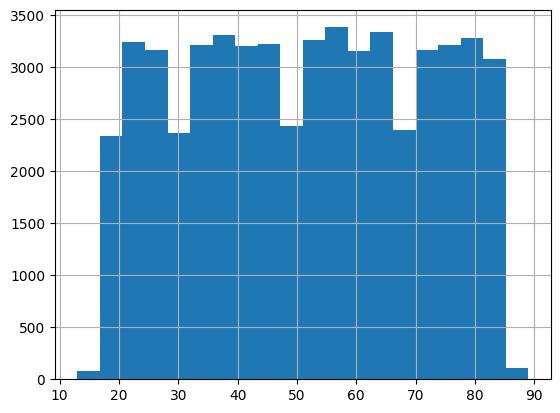

In [109]:
df["Age"].hist(bins=20)

In [110]:
##Medical conditions
df["Medical Condition"].value_counts()

,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


In [111]:
df.groupby("Medical Condition")["Age"].mean().sort_values(ascending=False)

,Age
Medical Condition,
Hypertension,51.717954
Asthma,51.595382
Diabetes,51.581814
Cancer,51.542123
Arthritis,51.540464
Obesity,51.233217


In [112]:
df["Blood Type"].value_counts()

,count
Blood Type,
A-,6898
A+,6896
B+,6885
AB+,6882
AB-,6874
B-,6872
O+,6855
O-,6804


In [113]:
df["Blood Type"].value_counts(normalize=True) * 100

,proportion
Blood Type,
A-,12.549576
A+,12.545937
B+,12.525925
AB+,12.520467
AB-,12.505913
B-,12.502274
O+,12.471346
O-,12.378561


### Finding

The patient population is almost evenly distributed by gender, with males representing approximately 50.02% and females 49.98% of records. Patient ages range from 13 to 89 years, with a median age of 52 years.

The six medical conditions are also relatively evenly represented, and average patient age is very similar across all conditions. Blood types are similarly balanced, with each blood type accounting for approximately 12.4%–12.5% of patient records.

Overall, the demographic variables in this synthetic dataset are highly balanced, with no single gender, medical condition, or blood type strongly dominating the patient population.

## 12.2 Hospital & Admission Analysis

In [114]:
##patients distributed across admission types?
df["Admission Type"].value_counts()

,count
Admission Type,
Elective,18473
Urgent,18391
Emergency,18102


In [115]:
df["Admission Type"].value_counts(normalize=True) * 100

,proportion
Admission Type,
Elective,33.608049
Urgent,33.458865
Emergency,32.933086


In [116]:
##Does admission type affect the length of stay?
df.groupby("Admission Type")["Length of Stay"].agg(
    ["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
Admission Type,,,,,
Emergency,18102,15.584134,16.0,1,30
Elective,18473,15.511178,15.0,1,30
Urgent,18391,15.403839,15.0,1,30


In [117]:
##Does a longer hospital stay correspond to higher billing?
df.groupby("Admission Type")["Billing Amount"].agg(
    ["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
Admission Type,,,,,
Elective,18437,25663.342261,25706.74550,9.238787,52764.27674
Urgent,18353,25568.439653,25595.59305,31.030955,52373.03237
Emergency,18070,25551.133763,25465.12284,23.727930,52271.66375


In [118]:
df[["Length of Stay", "Billing Amount"]].corr()

,Length of Stay,Billing Amount
Length of Stay,1.000000,-0.004801
Billing Amount,-0.004801,1.000000


### Finding

Admission types are relatively evenly distributed, with Elective admissions representing approximately 33.61%, Urgent 33.46%, and Emergency 32.93% of records.

Average Length of Stay is very similar across admission types. Emergency admissions have the longest average stay at approximately 15.58 days, compared with 15.51 days for Elective and 15.40 days for Urgent admissions.

Average billing also varies only slightly across admission types. The correlation between Length of Stay and Billing Amount is approximately -0.005, indicating almost no linear relationship between the two variables.

Therefore, longer hospital stays do not appear to be associated with higher billing amounts in this dataset.

## 12.3 Patient & Medical condition analysis

In [119]:
##Which medical conditions are most common?
df["Medical Condition"].value_counts()

,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


In [120]:
df["Medical Condition"].value_counts(normalize=True) * 100

,proportion
Medical Condition,
Arthritis,16.770367
Diabetes,16.766729
Hypertension,16.648474
Obesity,16.639377
Cancer,16.628461
Asthma,16.546592


In [121]:
##Which medical conditions have the highest average billing?
df.groupby("Medical Condition")["Billing Amount"].agg(
    ["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
Medical Condition,,,,,
Obesity,9127,25859.215373,26200.51454,53.931445,52024.72644
Diabetes,9197,25714.326349,25681.00803,31.030955,52211.85297
Asthma,9077,25685.385020,25684.40673,42.514589,52181.83779
Hypertension,9131,25559.844868,25337.53607,68.909747,52764.27674
Arthritis,9207,25542.898356,25628.30293,32.626843,52170.03685
Cancer,9121,25205.924207,24990.11413,9.238787,52373.03237


In [122]:
##Which medical conditions have the longest average hospital stay?
df.groupby("Medical Condition")["Length of Stay"].agg(
    ["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
Medical Condition,,,,,
Asthma,9095,15.677295,16.0,1,30
Arthritis,9218,15.504231,15.0,1,30
Cancer,9140,15.501204,15.0,1,30
Obesity,9146,15.447627,15.0,1,30
Hypertension,9151,15.436236,15.0,1,30
Diabetes,9216,15.430664,15.0,1,30


In [123]:
##Does gender affect billing?
df.groupby("Gender")["Billing Amount"].agg(
    ["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Gender,,,,,
Female,27411,25529.935010,25488.95537,23.727930,52764.27674
Male,27449,25659.242696,25721.51808,9.238787,52271.66375


In [124]:
##Does gender affect length of stay?
df.groupby("Gender")["Length of Stay"].agg(
    ["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Gender,,,,,
Female,27470,15.462687,15.0,1,30
Male,27496,15.535860,15.0,1,30


### Finding

The six medical conditions are relatively evenly represented, with each accounting for approximately 16.5%–16.8% of patient records.

Obesity has the highest average billing amount at approximately \$25,859, while Cancer has the lowest at approximately \$25,206. However, the overall differences in average billing between medical conditions are relatively small.

Average Length of Stay is also similar across conditions. Asthma has the highest average stay at approximately 15.68 days, while Diabetes has the lowest at approximately 15.43 days.

Male and female patients also have very similar average billing amounts and Length of Stay, suggesting that gender is not associated with substantial differences in these measures within this dataset.

## 12.4 Insurance & Billing Analysis

Insurance Provider
Medicare            25678.087847
Blue Cross          25639.269835
Aetna               25615.260975
Cigna               25582.227724
UnitedHealthcare    25458.893302
Name: Billing Amount, dtype: float64


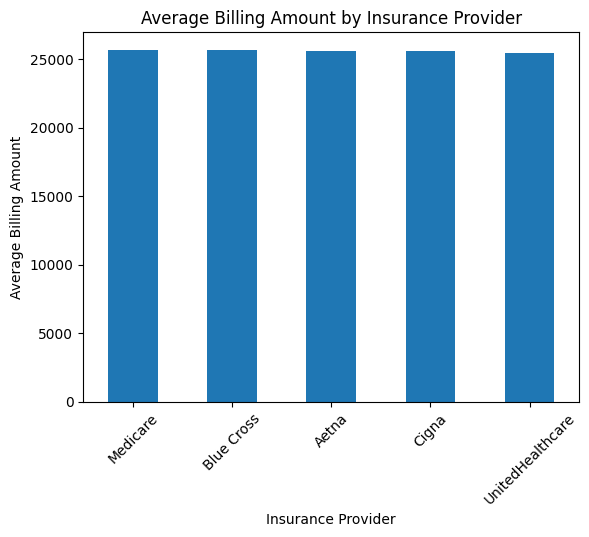

In [125]:

##Which insurance providers handle the most patient records, and are there meaningful differences in billing across providers?
insurance_billing = (df.groupby("Insurance Provider")["Billing Amount"]
      .mean()
      .sort_values(ascending=False))
print(insurance_billing)


insurance_billing.plot(kind="bar")

plt.title("Average Billing Amount by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=45)
plt.show()

In [126]:
df.groupby("Insurance Provider")["Billing Amount"].agg(
    ["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
Insurance Provider,,,,,
Medicare,11018,25678.087847,25683.36508,90.829943,52092.66990
Blue Cross,10937,25639.269835,25636.53810,42.514589,52764.27674
Aetna,10795,25615.260975,25849.05652,32.626843,52211.85297
Cigna,11115,25582.227724,25570.92844,38.969643,52170.03685
UnitedHealthcare,10995,25458.893302,25273.25662,9.238787,52373.03237


### Finding

Average billing amounts are relatively consistent across insurance providers. Medicare has the highest average billing amount at approximately \$25,678, while UnitedHealthcare has the lowest at approximately \$25,459. The small difference between providers suggests that insurance provider is not associated with substantial differences in average billing within this dataset.

## 12.5 Test Results & Medication Analysis

In [127]:
##How are test results distributed?

df["Test Results"].value_counts()

,count
Test Results,
Abnormal,18437
Normal,18331
Inconclusive,18198


In [128]:
df["Test Results"].value_counts(normalize=True) * 100

,proportion
Test Results,
Abnormal,33.542554
Normal,33.349707
Inconclusive,33.107739


In [129]:
##Do test results differ by medical condition?

condition_test_results = pd.crosstab(
    df["Medical Condition"],
    df["Test Results"],
    normalize="index") * 100

print(condition_test_results)

Test Results        Abnormal  Inconclusive     Normal
Medical Condition                                    
Arthritis          34.237362     33.217618  32.545021
Asthma             32.765256     32.974162  34.260583
Cancer             33.796499     33.183807  33.019694
Diabetes           33.973524     32.812500  33.213976
Hypertension       32.531964     33.526391  33.941646
Obesity            33.938334     32.932429  33.129237


In [130]:
# Medication distribution

print("Medication Counts:")
print(df["Medication"].value_counts())

print("\nMedication Percentages:")
print(df["Medication"].value_counts(normalize=True) * 100)

Medication Counts:
Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64

Medication Percentages:
Medication
Lipitor        20.081505
Ibuprofen      20.054215
Aspirin        19.983262
Paracetamol    19.948696
Penicillin     19.932322
Name: proportion, dtype: float64


### Finding

Test results are almost evenly distributed, with Abnormal, Normal, and Inconclusive results each representing approximately one-third of records. Test-result distributions also remain relatively consistent across medical conditions, with only small differences in abnormal-result rates.

Medication usage is similarly balanced, with each of the five medications accounting for approximately 20% of records.

## 12.6 Time Trend Analysis

In [131]:
df["Admission Year"] = df["Date of Admission"].dt.year
df["Admission Month"] = df["Date of Admission"].dt.month

print(df[["Date of Admission", "Admission Year", "Admission Month"]].head())

  Date of Admission  Admission Year  Admission Month
0        2024-01-31            2024                1
1        2019-08-20            2019                8
2        2022-09-22            2022                9
3        2020-11-18            2020               11
4        2022-09-19            2022                9


In [132]:
##Admission by year

admissions_by_year = (
    df["Admission Year"]
    .value_counts()
    .sort_index())

print(admissions_by_year)

Admission Year
2019     7300
2020    11172
2021    10816
2022    10915
2023    10936
2024     3827
Name: count, dtype: int64


In [133]:
#monthly admission trend

df["Admission Year-Month"] = (
    df["Date of Admission"].dt.to_period("M"))

monthly_admissions = (
    df.groupby("Admission Year-Month").size())

print(monthly_admissions)

Admission Year-Month
2019-05    677
2019-06    899
2019-07    951
2019-08    985
2019-09    924
          ... 
2024-01    903
2024-02    869
2024-03    902
2024-04    941
2024-05    212
Freq: M, Length: 61, dtype: int64


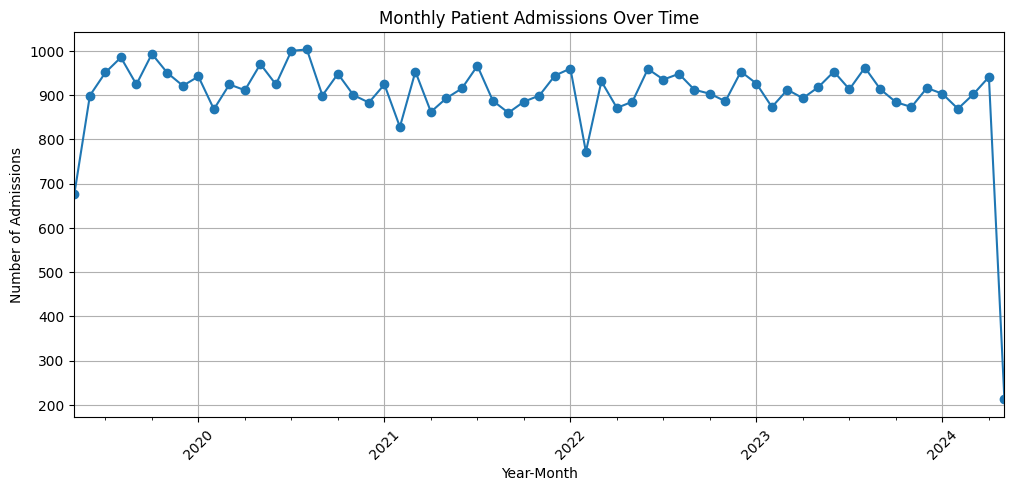

In [134]:
monthly_admissions.plot(
    kind="line",
    figsize=(12, 5),
    marker="o")

plt.title("Monthly Patient Admissions Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Finding

Monthly patient admissions remained relatively stable throughout the dataset, generally ranging between approximately 850 and 1,000 admissions per month. No clear long-term upward or downward trend is visible across the complete years.

The lower admission counts in May 2019 and May 2024 should not be interpreted as significant declines because these are partial months in the dataset.

## 12.7 Key Findings & Business Insights

### Key Findings

1. **Patient Demographics**
   - The dataset contains 54,966 cleaned patient records.
   - Gender distribution is almost perfectly balanced, with approximately 50% male and 50% female patients.
   - Patients have a median age of 52 years, with ages ranging from 13 to 89.
   - Average age is very similar across all medical conditions.

2. **Medical Conditions**
   - Arthritis, Diabetes, Hypertension, Obesity, Cancer, and Asthma are almost evenly represented.
   - There are no major differences in average patient age across medical conditions.
   - Average length of stay is also relatively similar across medical conditions.

3. **Hospital Admissions**
   - Emergency, Urgent, and Elective admissions are distributed relatively evenly.
   - Average length of stay is approximately 15.5 days.
   - Length of stay differs only slightly between admission types.

4. **Billing**
   - Average billing is approximately \$25.6K for valid billing records.
   - Billing amounts are relatively similar across admission types and insurance providers.
   - Medicare has the highest average billing at approximately \$25,678, while UnitedHealthcare has the lowest at approximately \$25,459.
   - Length of stay and billing amount have almost no linear relationship, with a correlation of approximately -0.005.

5. **Insurance Providers**
   - Average billing is highly consistent across the five insurance providers.
   - The difference between the highest and lowest average billing provider is relatively small, suggesting that insurance provider is not strongly associated with billing differences in this dataset.

6. **Test Results and Medication**
   - Normal, Abnormal, and Inconclusive test results each represent approximately one-third of records.
   - Test-result distributions remain relatively consistent across medical conditions.
   - Medication usage is also highly balanced, with each medication accounting for approximately 20% of records.

7. **Admission Trends**
   - Admissions remain relatively stable across the complete years from 2020 to 2023.
   - Monthly admissions generally remain within a similar range, with normal month-to-month fluctuations.
   - The lower counts in May 2019 and May 2024 are caused by partial-month coverage and should not be interpreted as significant declines.

### 12.8 Business Interpretation

Overall, the dataset shows relatively stable patterns across patient demographics, medical conditions, admission types, insurance providers, medications, and test results. No single category appears to dominate hospital activity or billing.

The analysis also indicates that longer hospital stays are not associated with higher billing amounts in this dataset. Hospital admissions remain relatively stable over time, suggesting no clear long-term growth or decline during the complete years analysed.

Because the dataset is synthetic and many categorical variables are intentionally balanced, these findings should be interpreted as analytical observations from the dataset rather than conclusions about real-world healthcare populations.

## 13. Export Cleaned Dataset

In [135]:
df.to_csv("healthcare_cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
